# Evaluación de clasificadores . Derecho a las Víctimas

## ¿Qué hace este notebook?

Compara las predicciones de cualquier clasificador contra las etiquetas reales del test set y muestra:

- Métricas principales (Accuracy, F1, Precision, Recall, Kappa)
- Matriz de confusión
- Análisis de errores 

**Para evaluar un clasificador nuevo:** se cambian las rutas en la Sección 1 y se corren todas las celdas 


### Nota sobre las métricas

La métrica principal es **F1 macro**, no Accuracy, porque las clases están desbalanceadas (más negativos que positivos). Además para Kappa el criterio es el siguiente:

| Kappa     | Interpretación   |
| < 0.0     | Peor que el azar |
| 0.0 – 0.2 | Leve             |
| 0.2 – 0.4 | Débil            |
| 0.4 – 0.6 | Moderado         |
| 0.6 – 0.8 | Bueno            | 
| > 0.8     | Excelente        |

> **Observación:** los falsos negativos (predijo NO, era SÍ) son más costosos que los falsos positivos en este dominio, porque perder una norma de derechos de víctimas es peor que incluir una de más.

## 1. Configuración

**Solo modificar esta sección para evaluar un clasificador nuevo.**

In [5]:
#  Archivo con las predicciones del clasificador a evaluar 
# Debe tener columnas: 'Número' y 'caso_ok' (la predicción)
# Opcionalmente: 'Justificación' para el análisis de errores
FILE_PREDICCIONES  = 'resultado_ollama3.1_prompt1.xlsx'

# Nombre del clasificador (aparece en los gráficos y tablas)
NOMBRE_CLASIFICADOR = 'Ollama 3.1 (8B)'

# Archivo original con las etiquetas reales
FILE_ORIGINAL = 'Normativa_nacional_víctimas_1869-2023.xlsx'

#Archivo test con las etiquetas originales 
FILE_TEST_ETIQUETAS =  'test_con_etiqueta.xlsx'

# Parámetros del split
TEST_SIZE    = 0.30
RANDOM_STATE = 42

## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, cohen_kappa_score
)
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


## 3. Carga y merge de datos

In [6]:
df_pred = pd.read_excel(FILE_PREDICCIONES)
df_test = pd.read_excel(FILE_TEST_ETIQUETAS)
df_pred['Número'] = df_pred['Número'].astype(str).str.strip()
df_test['Número'] = df_test['Número'].astype(str).str.strip()

merged = df_pred.merge(
    df_test[['Número', 'caso_ok']],
    on='Número',
    suffixes=('_pred', '_real')
)
merged = merged[merged['caso_ok_pred'] != -1]
n = len(merged)

y_pred = merged['caso_ok_pred']
y_real = merged['caso_ok_real']

## 4. Métricas

In [7]:
# Tabla de métricas
metricas = {
    'Accuracy':              round(accuracy_score(y_real, y_pred), 3),
    'F1 macro':            round(f1_score(y_real, y_pred, average='macro'), 3),
    'F1 positivos (SÍ)':     round(f1_score(y_real, y_pred, pos_label=1), 3),
    'F1 negativos (NO)':     round(f1_score(y_real, y_pred, pos_label=0), 3),
    'Precision positivos':   round(precision_score(y_real, y_pred, pos_label=1), 3),
    'Recall positivos':      round(recall_score(y_real, y_pred, pos_label=1), 3),
    'Kappa':                 round(cohen_kappa_score(y_real, y_pred), 3),
}

df_metricas = pd.DataFrame(
    metricas.items(), columns=['Métrica', 'Valor']
).set_index('Métrica')

print(f'Clasificador: {NOMBRE_CLASIFICADOR}')
print()
display(
    df_metricas.style
    .format('{:.3f}')
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=0)
    .set_caption(f'Métricas — {NOMBRE_CLASIFICADOR}')
)

Clasificador: Ollama 3.1 (8B)



,Valor
Métrica,
Accuracy,0.500
F1 macro,0.497
F1 positivos (SÍ),0.537
F1 negativos (NO),0.456
Precision positivos,0.409
Recall positivos,0.783
Kappa,0.098


In [8]:
# ── Reporte detallado por clase ───────────────────────────────────────────────
print(classification_report(
    y_real, y_pred,
    labels=[0, 1],
    target_names=['NO víctima (0)', 'SÍ víctima (1)'],
    zero_division=0
))

                precision    recall  f1-score   support

NO víctima (0)       0.72      0.33      0.46        39
SÍ víctima (1)       0.41      0.78      0.54        23

      accuracy                           0.50        62
     macro avg       0.57      0.56      0.50        62
  weighted avg       0.61      0.50      0.49        62



## 5. Matriz de confusión

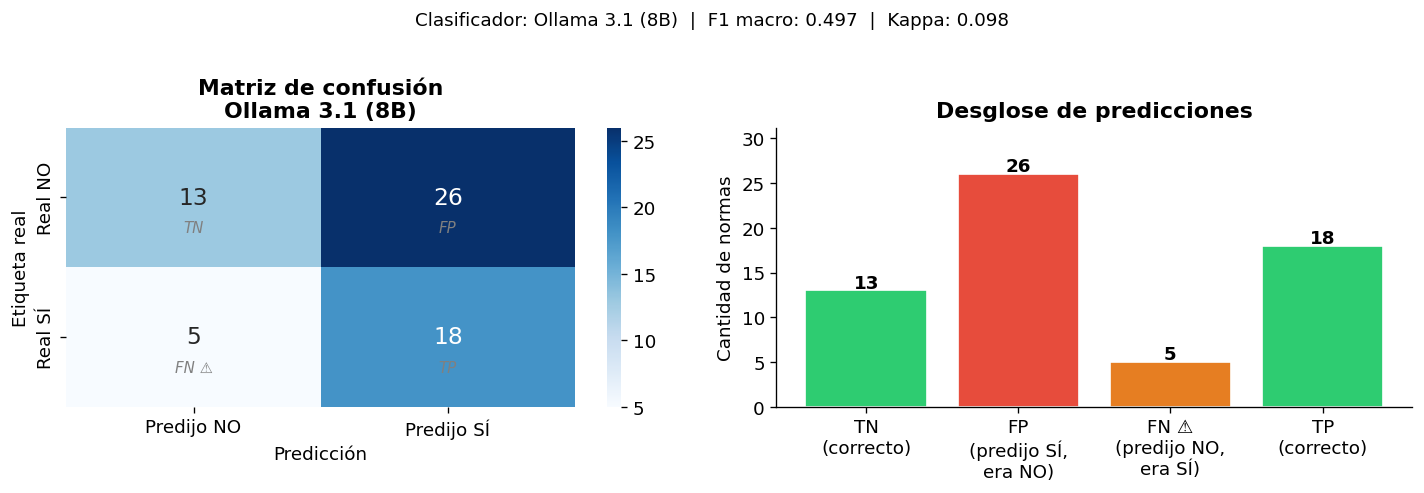

TN=13  FP=26  FN=5  TP=18
Total correctos: 31/62 (50.0%)
Total errores:   31/62 (50.0%)


In [9]:
cm = confusion_matrix(y_real, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Predijo NO', 'Predijo SÍ'],
    yticklabels=['Real NO', 'Real SÍ'],
    annot_kws={'size': 14}
)
ax.set_title(f'Matriz de confusión\n{NOMBRE_CLASIFICADOR}', fontweight='bold')
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción')
for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN ⚠'), ((1,1),'TP')]:
    ax.text(j+0.5, i+0.75, label, ha='center', fontsize=9, color='gray', style='italic')


ax2 = axes[1]
categorias = ['TN\n(correcto)', 'FP\n(predijo SÍ,\nera NO)', 'FN ⚠\n(predijo NO,\nera SÍ)', 'TP\n(correcto)']
valores    = [tn, fp, fn, tp]
colores    = ['#2ecc71', '#e74c3c', '#e67e22', '#2ecc71']
bars = ax2.bar(categorias, valores, color=colores, edgecolor='white')
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')
ax2.set_title('Desglose de predicciones', fontweight='bold')
ax2.set_ylabel('Cantidad de normas')
ax2.set_ylim(0, max(valores) * 1.2)

n = len(merged)
plt.suptitle(f'Clasificador: {NOMBRE_CLASIFICADOR}  |  F1 macro: {metricas["F1 macro"]:.3f}  |  Kappa: {metricas["Kappa"]:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Total correctos: {tn+tp}/{n} ({(tn+tp)/n:.1%})')
print(f'Total errores:   {fp+fn}/{n} ({(fp+fn)/n:.1%})')

## 6. Análisis de errores

Se muestran primero los **falsos negativos** (predijo NO, era SÍ) porque son más costosos.

In [10]:
errores = merged[merged['caso_ok_pred'] != merged['caso_ok_real']].copy()
errores['tipo_error'] = errores.apply(
    lambda r: 'FN — predijo NO, era SÍ' if r['caso_ok_pred'] == 0
              else 'FP — predijo SÍ, era NO',
    axis=1
)

print(f'Total errores: {len(errores)} de {n} ({len(errores)/n:.1%})')
print(errores['tipo_error'].value_counts().to_string())

Total errores: 31 de 62 (50.0%)
tipo_error
FP — predijo SÍ, era NO    26
FN — predijo NO, era SÍ     5


In [11]:
# ── Falsos negativos ──────────────────────────────────────────────────────────
fn_df = errores[errores['tipo_error'] == 'FN — predijo NO, era SÍ']

print(f'⚠️  Falsos negativos: {len(fn_df)} casos')
print('(El clasificador dijo NO pero la etiqueta real era SÍ)')
print()

cols = ['Número', 'Título'] if 'Título' in fn_df.columns else ['Número']
if 'Justificación' in fn_df.columns:
    cols.append('Justificación')

pd.set_option('display.max_colwidth', 80)
display(fn_df[cols].reset_index(drop=True))

⚠️  Falsos negativos: 5 casos
(El clasificador dijo NO pero la etiqueta real era SÍ)



,Número,Título,Justificación
0,18577,RELACIONES INTERNACIONALES,0
1,888,DUELO NACIONAL,0
2,840,DUELO NACIONAL,0
3,490,MONUMENTOS NACIONALES,0
4,787,ATENTADOS EMBAJADA DE ISRAEL Y AMIA,0


In [12]:
# ── Falsos positivos ──────────────────────────────────────────────────────────
fp_df = errores[errores['tipo_error'] == 'FP — predijo SÍ, era NO']

print(f'Falsos positivos: {len(fp_df)} casos')
print('(El clasificador dijo SÍ pero la etiqueta real era NO)')
print()

cols = ['Número', 'Título'] if 'Título' in fp_df.columns else ['Número']
if 'Justificación' in fp_df.columns:
    cols.append('Justificación')

display(fp_df[cols].reset_index(drop=True))

Falsos positivos: 26 casos
(El clasificador dijo SÍ pero la etiqueta real era NO)



,Número,Título,Justificación
0,26004,ACUERDOS,1
1,25632,CONVENCIONES,1
2,844,FONDO DE ASISTENCIA DIRECTA A VICTIMAS DE TRATA,1
3,21507,FUERZAS ARMADAS Y DE SEGURIDAD,1
4,606,JEFATURA DE GABINETE DE MINISTROS,1
5,235,PROTECCION CONTRA LA VIOLENCIA FAMILIAR,1
6,25742,CODIGO PENAL,1
7,26378,CONVENCIONES,1
8,27149,MINISTERIO PÚBLICO DE LA DEFENSA DE LA NACIÓN,1
9,174,ADMINISTRACION PUBLICA NACIONAL,1
